# Test VII — Physics-Guided ML: Lensiformer (PINN Classifier)

**Author:** Utkarsh Karki  
**Project:** DeepLense GSoC 2026 Evaluation

---

## Strategy & Architecture

### Why Physics-Informed?

Standard CNNs classify lensing images by learning purely statistical patterns. A **Physics-Informed Neural Network (PINN)** instead **embeds domain knowledge** — the gravitational lensing equations — directly into the architecture. This forces the model to reason about physical structure rather than just texture.

### The Lensiformer Architecture

```
Input Image (B, 1, 150, 150)
        |
        v
+------------------------+
| Inverse Lens Layer     |  <- Physics encoder
|  k-predictor CNN       |     Predicts kappa (convergence)
|  psi-residual CNN      |     Predicts lensing potential
|  beta = theta - grad_psi|    Source reconstruction
+-----------|------------+
            | source + physics_data
            v
+------------------------+
| Shifted Patch Tokenization (SPT)
|  5 diagonal shifts -> concat
|  Conv patch embedding  |
+-----------|------------+
            |
            v
+------------------------+
| Learnable Gating Fusion|  gate = sigmoid(W.[src,orig])
+-----------|------------+
            |
            v
+------------------------+
| Transformer Blocks x6  |  <- Locality Self-Attention
|  Learnable temperature  |     Diagonal masking
+-----------|------------+
            | CLS token
            v
+------------------------+
| MC Dropout + Head      |  -> 3-class logits
+------------------------+
```

### Physics Losses

| Loss | Formula | Purpose |
|------|---------|--------|
| **L_physics** | `||I - forward_lens(source)||^2` | Reconstruction consistency |
| **L_k_smooth** | `||grad_k||^2` | k-map smoothness |
| **L_res** | `||psi_res||^2` | Penalise residual |
| **L_alpha** | `||alpha||^2` | Deflection energy |

Physics losses use **curriculum learning** (starts epoch 10, full weight by epoch 50).

### Baseline: ResNet-18 (custom, 1-channel, 150x150)

The baseline is `ResNet18Baseline` — a custom ResNet-18 adapted for 1-channel 150x150 grayscale lensing images, trained without any physics information.

## 1. Setup & Imports

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
from IPython.display import Image as IPImage, display
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report
import torch.nn.functional as F
from tqdm.notebook import tqdm

from pinn_model import config
from pinn_model.lensiformer import Lensiformer
from pinn_model.baseline    import ResNet18Baseline
from pinn_model.dataset     import get_dataloaders

DEVICE      = config.DEVICE
CLASS_NAMES = config.CLASS_NAMES
print(f"Device  : {DEVICE}")
print(f"Classes : {CLASS_NAMES}")

Device  : cuda
Classes : ['no', 'sphere', 'vort']


## 2. Load Trained Lensiformer Weights

In [2]:
CKPT_PATH = os.path.join('checkpoints', 'pinn', 'lensiformer_best.pth')

model = Lensiformer().to(DEVICE)
ckpt  = torch.load(CKPT_PATH, map_location=DEVICE)
model.load_state_dict(ckpt['model_state_dict'])

print(f"Loaded Lensiformer from epoch {ckpt.get('epoch', '?')}")
print(f"Best val accuracy : {ckpt.get('best_val_acc', ckpt.get('val_acc', '?'))}%")
print(f"Parameters        : {sum(p.numel() for p in model.parameters()):,}")
model.eval()

Loaded Lensiformer from epoch 99
Best val accuracy : 36.36%
Parameters        : 3,917,157


Lensiformer(
  (inverse_lens): InverseLensLayer(
    (coords): CoordinateSystem()
    (k_predictor): KPredictor(
      (net): Sequential(
        (0): Conv2d(4, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): GroupNorm(8, 32, eps=1e-05, affine=True)
        (2): SiLU()
        (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): GroupNorm(8, 32, eps=1e-05, affine=True)
        (5): SiLU()
        (6): Conv2d(32, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (7): GroupNorm(4, 16, eps=1e-05, affine=True)
        (8): SiLU()
        (9): Conv2d(16, 1, kernel_size=(1, 1), stride=(1, 1))
      )
    )
    (psi_residual): PsiResidualPredictor(
      (net): Sequential(
        (0): Conv2d(4, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): GroupNorm(4, 16, eps=1e-05, affine=True)
        (2): SiLU()
        (3): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): GroupNorm(4, 16, 

## 3. Load Validation Data

In [3]:
_, val_loader = get_dataloaders(batch_size=16)
print(f"Validation batches: {len(val_loader)}")

Loaded 30000 images from C:\Users\utkar\Desktop\DEEPLENSE\src\dataset\test7\dataset\train
  no: 10000
  sphere: 10000
  vort: 10000
Loaded 7500 images from C:\Users\utkar\Desktop\DEEPLENSE\src\dataset\test7\dataset\val
  no: 2500
  sphere: 2500
  vort: 2500
Train batches: 1875, Val batches: 469
Validation batches: 469


## 4. Run Inference on Validation Set

In [4]:
all_probs, all_labels = [], []

model.eval()
with torch.no_grad():
    for images, labels in tqdm(val_loader, desc='Lensiformer inference'):
        images = images.to(DEVICE)
        probs  = F.softmax(model(images), dim=-1)
        all_probs.append(probs.cpu().numpy())
        all_labels.append(labels.numpy())

all_probs  = np.concatenate(all_probs)
all_labels = np.concatenate(all_labels)
all_preds  = all_probs.argmax(axis=1)

overall_acc = (all_preds == all_labels).mean() * 100
print(f"\nOverall Accuracy: {overall_acc:.2f}%")

Lensiformer inference:   0%|          | 0/469 [00:00<?, ?it/s]


Overall Accuracy: 36.36%


## 5. ROC Curves & AUC Scores

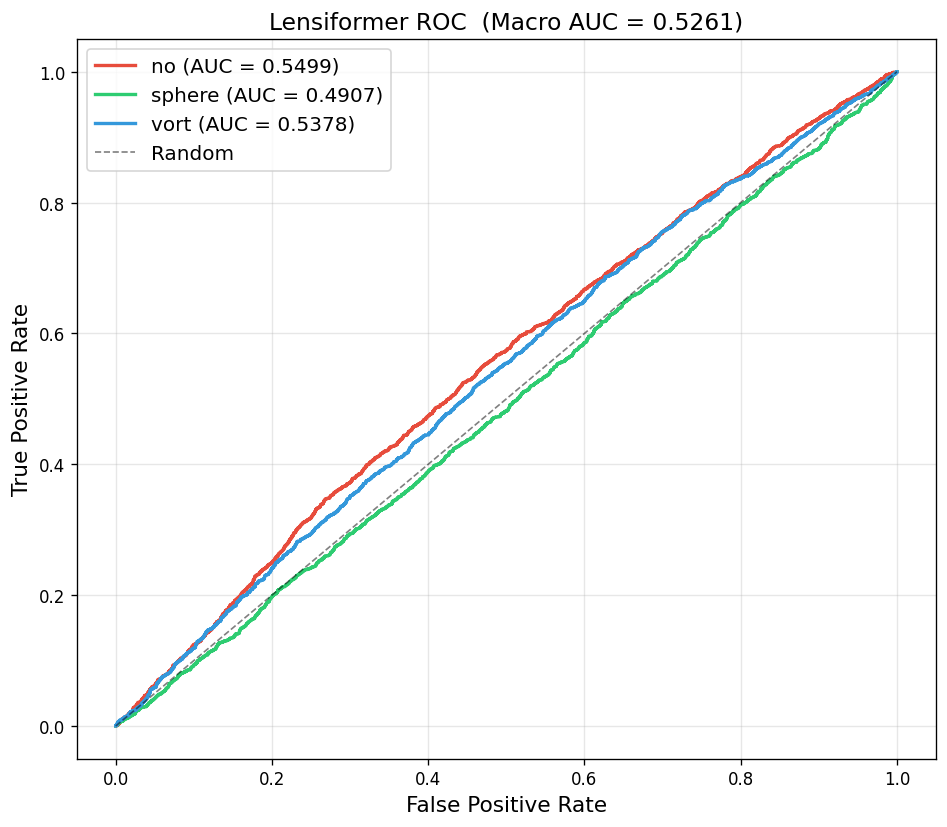


AUC Scores:
  no        : 0.5499
  sphere    : 0.4907
  vort      : 0.5378
  macro     : 0.5261


In [5]:
n_classes     = config.NUM_CLASSES
labels_onehot = np.eye(n_classes)[all_labels]
colors        = ['#e74c3c', '#2ecc71', '#3498db']
lf_auc        = {}

fig, ax = plt.subplots(figsize=(8, 7))

for i, (name, color) in enumerate(zip(CLASS_NAMES, colors)):
    fpr, tpr, _ = roc_curve(labels_onehot[:, i], all_probs[:, i])
    score       = auc(fpr, tpr)
    lf_auc[name] = score
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f'{name} (AUC = {score:.4f})')

lf_auc['macro'] = np.mean([lf_auc[n] for n in CLASS_NAMES])

ax.plot([0,1],[0,1], 'k--', lw=1, alpha=0.5, label='Random')
ax.set_xlabel('False Positive Rate', fontsize=13)
ax.set_ylabel('True Positive Rate',  fontsize=13)
ax.set_title(f'Lensiformer ROC  (Macro AUC = {lf_auc["macro"]:.4f})', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join('results','pinn','roc_lensiformer.png'), dpi=150, bbox_inches='tight')
plt.show()

print("\nAUC Scores:")
for k, v in lf_auc.items():
    print(f"  {k:10s}: {v:.4f}")

## 6. Classification Report

In [6]:
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

              precision    recall  f1-score   support

          no       0.37      0.54      0.44      2500
      sphere       0.35      0.04      0.08      2500
        vort       0.36      0.51      0.42      2500

    accuracy                           0.36      7500
   macro avg       0.36      0.36      0.31      7500
weighted avg       0.36      0.36      0.31      7500



## 7. Confusion Matrix

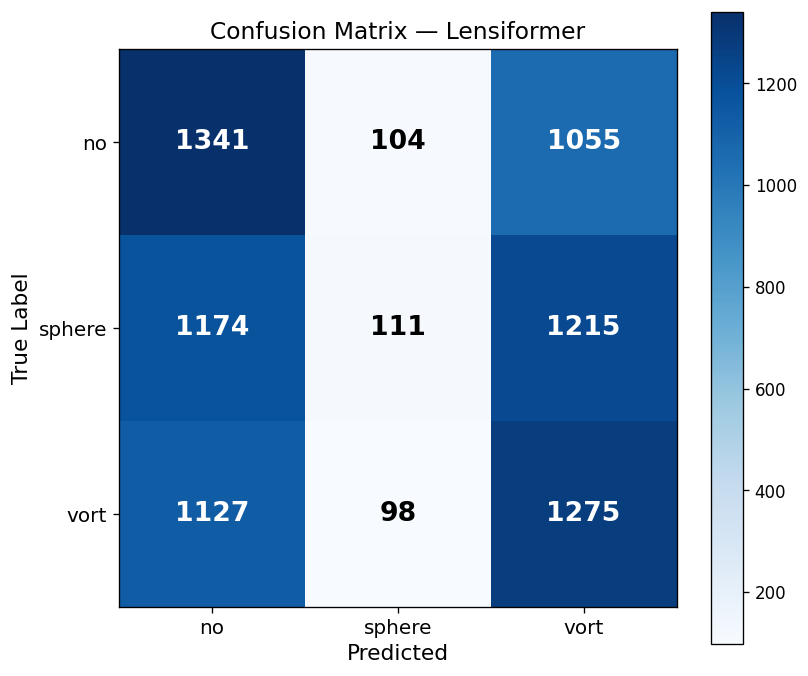

In [7]:
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap='Blues')

for i in range(len(cm)):
    for j in range(len(cm)):
        color = 'white' if cm[i,j] > cm.max()/2 else 'black'
        ax.text(j, i, str(cm[i,j]), ha='center', va='center',
                color=color, fontsize=16, fontweight='bold')

ax.set_xticks(range(n_classes)); ax.set_xticklabels(CLASS_NAMES, fontsize=12)
ax.set_yticks(range(n_classes)); ax.set_yticklabels(CLASS_NAMES, fontsize=12)
ax.set_xlabel('Predicted', fontsize=13)
ax.set_ylabel('True Label', fontsize=13)
ax.set_title('Confusion Matrix — Lensiformer', fontsize=14)
plt.colorbar(im)
plt.tight_layout()
plt.savefig(os.path.join('results','pinn','cm_lensiformer.png'), dpi=150, bbox_inches='tight')
plt.show()

## 8. ResNet-18 Baseline Inference (Test I Comparison)

> The baseline is `ResNet18Baseline` — a custom ResNet-18 for 1-channel 150x150 images (no physics), trained alongside the Lensiformer.

In [8]:
RESNET_CKPT = os.path.join('checkpoints', 'pinn', 'resnet_best.pth')

resnet = ResNet18Baseline().to(DEVICE)
ckpt_r = torch.load(RESNET_CKPT, map_location=DEVICE)
resnet.load_state_dict(ckpt_r['model_state_dict'])
resnet.eval()
print(f"ResNet-18 loaded from epoch {ckpt_r.get('epoch','?')} "
      f"| val acc: {ckpt_r.get('best_val_acc', ckpt_r.get('val_acc','?'))}%")

rn_probs, rn_labels = [], []
with torch.no_grad():
    for images, labels in tqdm(val_loader, desc='ResNet-18 inference'):
        images = images.to(DEVICE)
        probs  = F.softmax(resnet(images), dim=-1)
        rn_probs.append(probs.cpu().numpy())
        rn_labels.append(labels.numpy())

rn_probs  = np.concatenate(rn_probs)
rn_labels = np.concatenate(rn_labels)
rn_oh     = np.eye(n_classes)[rn_labels]

rn_auc = {}
for i, name in enumerate(CLASS_NAMES):
    fpr, tpr, _ = roc_curve(rn_oh[:, i], rn_probs[:, i])
    rn_auc[name] = auc(fpr, tpr)
rn_auc['macro'] = np.mean([rn_auc[n] for n in CLASS_NAMES])
print("ResNet-18 AUC computed.")

ResNet-18 loaded from epoch 1 | val acc: 35.14666666666667%


ResNet-18 inference:   0%|          | 0/469 [00:00<?, ?it/s]

ResNet-18 AUC computed.


## 9. AUC Comparison Table: ResNet-18 vs Lensiformer

Class          ResNet-18 (baseline)     Lensiformer (PINN)    Delta AUC
----------------------------------------------------------------------
no                           0.5271                 0.5499      +0.0228
sphere                       0.5096                 0.4907      -0.0189
vort                         0.5214                 0.5378      +0.0164
macro                        0.5193                 0.5261      +0.0068


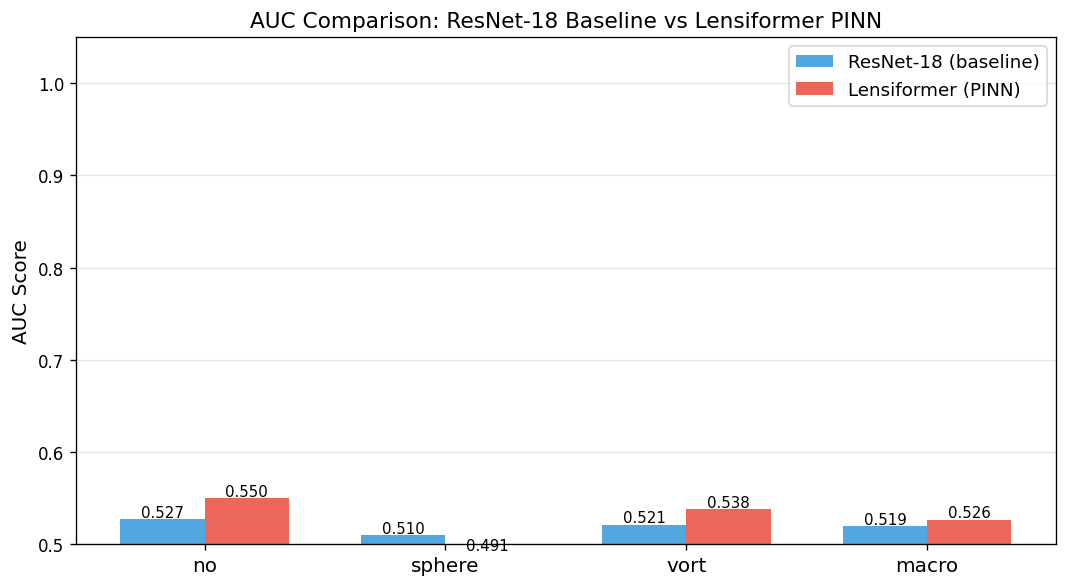

In [9]:
print(f"{'Class':<12} {'ResNet-18 (baseline)':>22} {'Lensiformer (PINN)':>22} {'Delta AUC':>12}")
print('-' * 70)
for k in list(CLASS_NAMES) + ['macro']:
    rn_v  = rn_auc[k]
    lf_v  = lf_auc[k]
    delta = lf_v - rn_v
    sign  = '+' if delta >= 0 else ''
    print(f"{k:<12} {rn_v:>22.4f} {lf_v:>22.4f} {sign+f'{delta:.4f}':>12}")

# Bar chart
keys  = list(CLASS_NAMES) + ['macro']
x     = np.arange(len(keys))
w     = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - w/2, [rn_auc[k] for k in keys], w,
            label='ResNet-18 (baseline)', color='#3498db', alpha=0.85)
b2 = ax.bar(x + w/2, [lf_auc[k] for k in keys], w,
            label='Lensiformer (PINN)',   color='#e74c3c', alpha=0.85)

for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{bar.get_height():.3f}', ha='center', fontsize=9)

ax.set_ylim(0.5, 1.05)
ax.set_xticks(x); ax.set_xticklabels(keys, fontsize=12)
ax.set_ylabel('AUC Score', fontsize=12)
ax.set_title('AUC Comparison: ResNet-18 Baseline vs Lensiformer PINN', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(os.path.join('results','pinn','auc_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

## 10. Training Curves

=== Lensiformer Training Curves ===


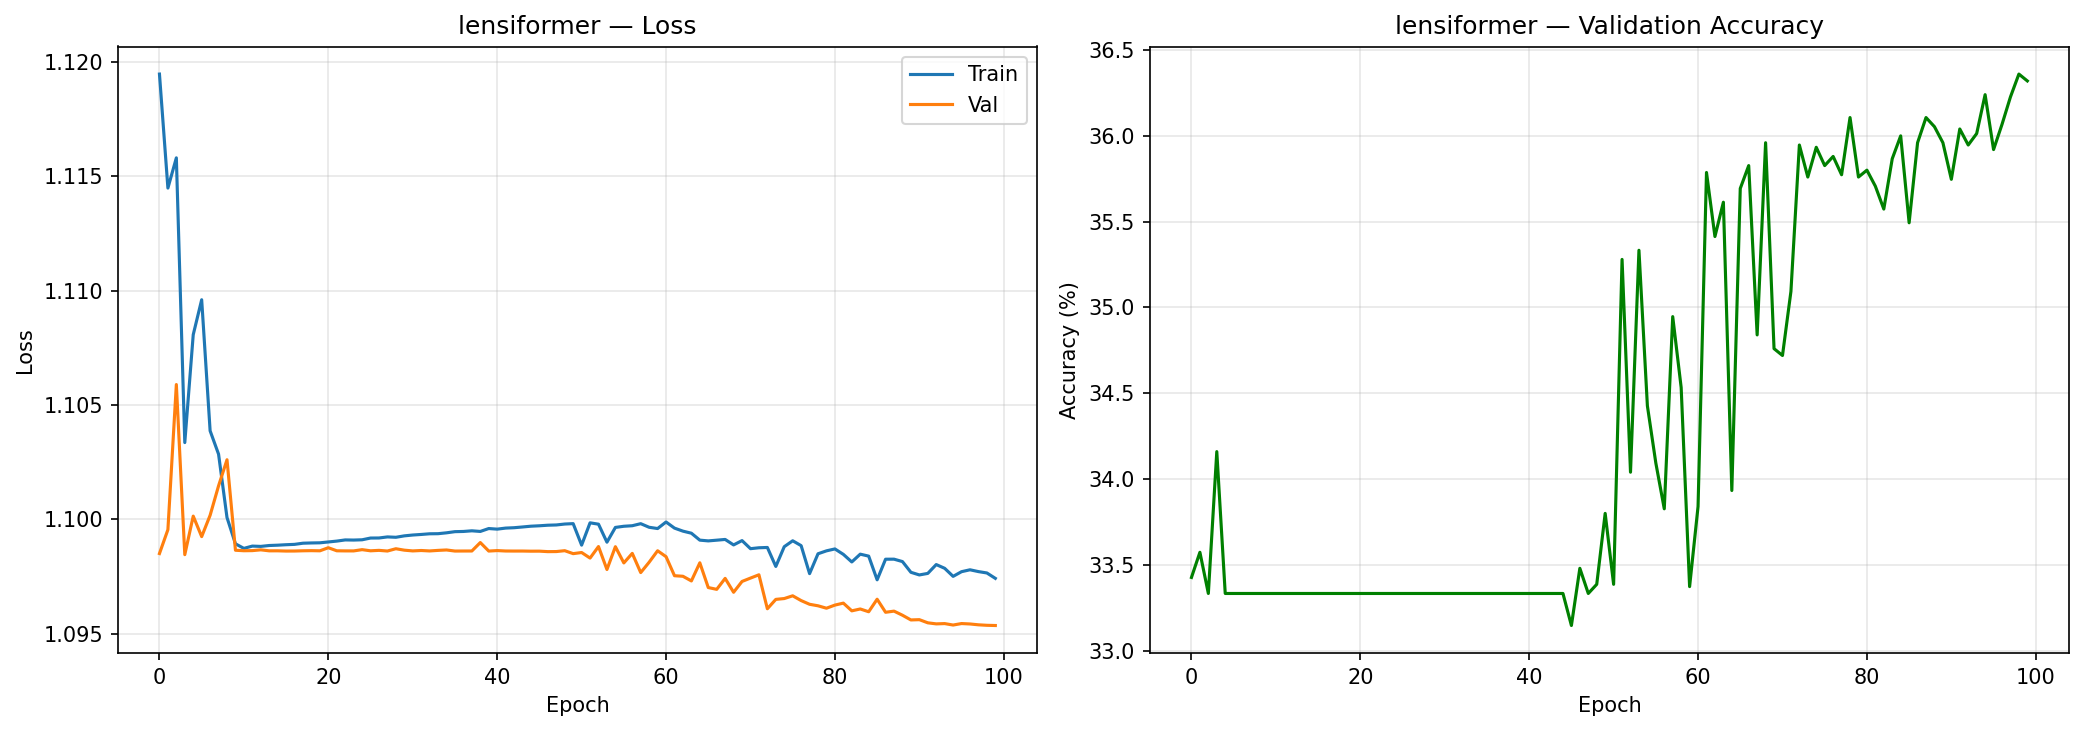

=== Lensiformer Physics Loss Breakdown ===


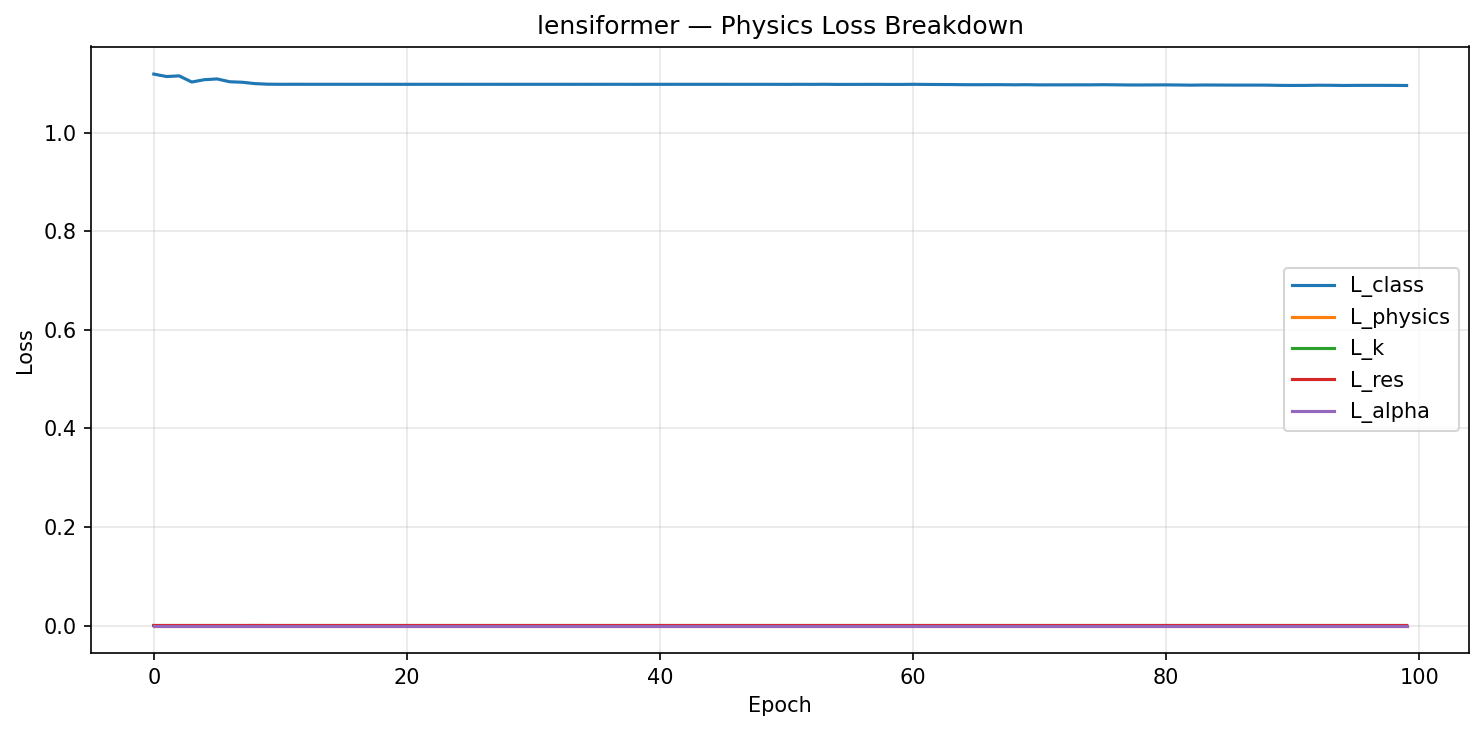

=== ResNet-18 Training Curves ===


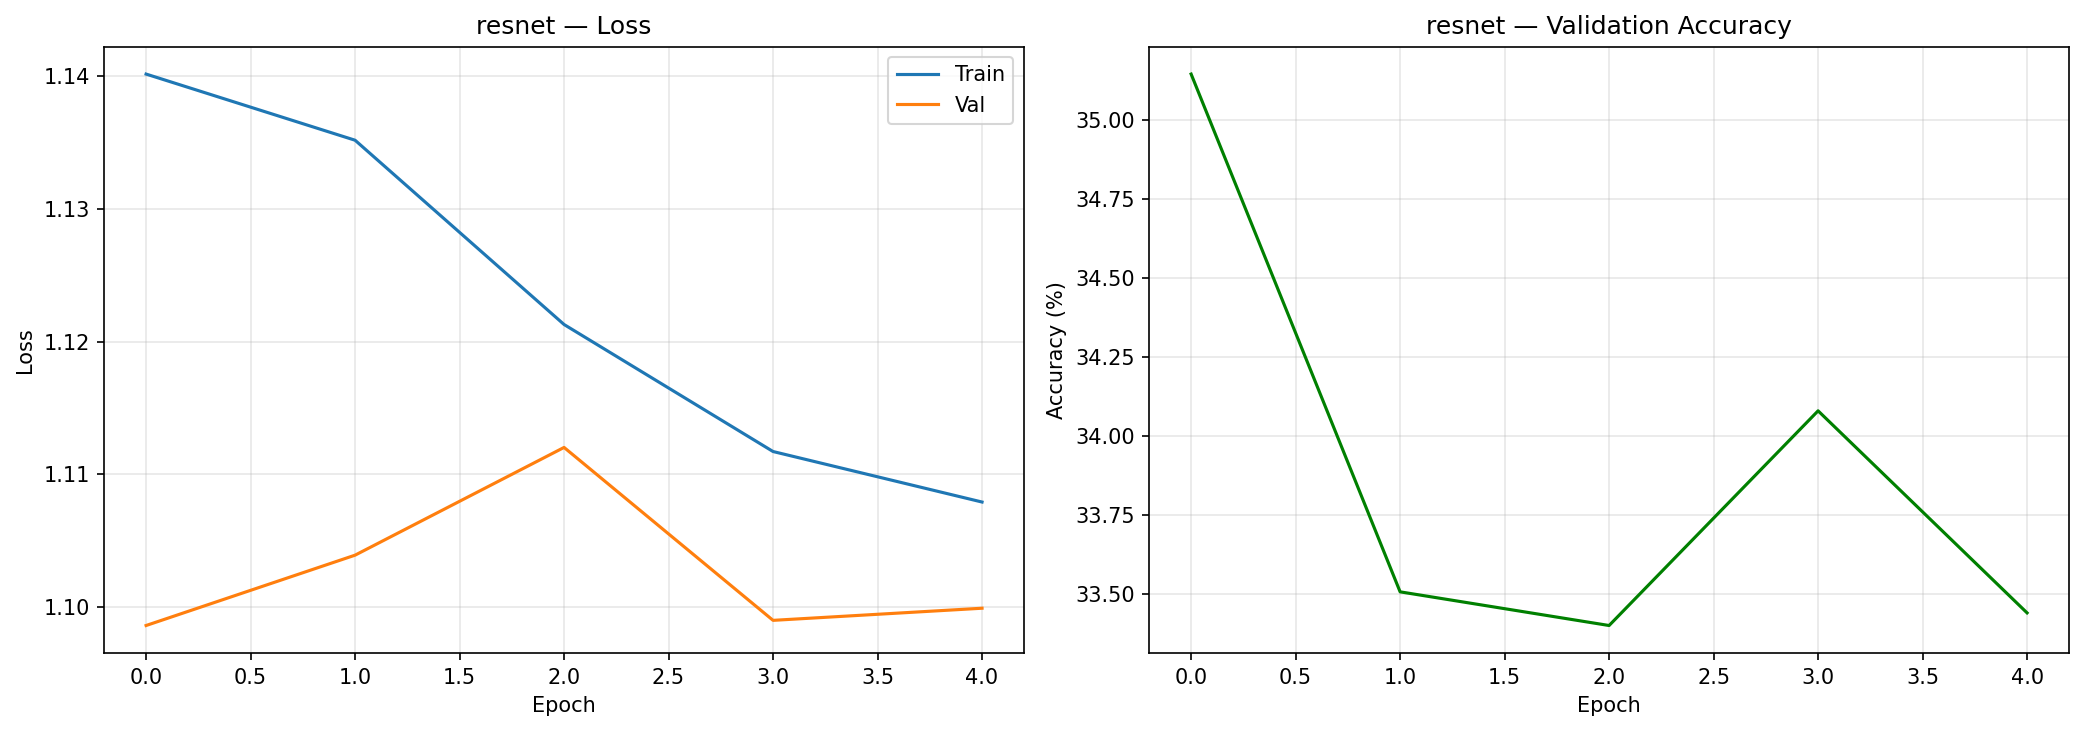

In [10]:
for title, fname in [
    ('Lensiformer Training Curves',       'lensiformer_curves.png'),
    ('Lensiformer Physics Loss Breakdown','lensiformer_physics_losses.png'),
    ('ResNet-18 Training Curves',         'resnet_curves.png'),
]:
    path = os.path.join('results', 'pinn', fname)
    if os.path.exists(path):
        print(f"=== {title} ===")
        display(IPImage(filename=path, width=800))
    else:
        print(f"[Not found] {path}")

## 11. Physics Visualisations

The `InverseLensLayer` produces three physically meaningful outputs:

| Map | Meaning |
|-----|---------|
| **kappa-map** | Convergence — mass density at each pixel |
| **alpha_x, alpha_y** | Deflection angle field |
| **Reconstructed source** | De-lensed background galaxy |

In [11]:
# Gather 2 samples per class with physics outputs
model.eval()
samples = {i: [] for i in range(3)}

with torch.no_grad():
    for images, labels in val_loader:
        for i in range(len(labels)):
            label = labels[i].item()
            if len(samples[label]) < 2:
                img = images[i:i+1].to(DEVICE)
                logits, physics = model(img, return_physics=True)
                samples[label].append({
                    'image':   img.cpu().squeeze(),
                    'k':       physics['k'].cpu().squeeze(),
                    'alpha_x': physics['alpha_x'].cpu().squeeze(),
                    'alpha_y': physics['alpha_y'].cpu().squeeze(),
                    'source':  physics['source'].cpu().squeeze(),
                    'pred':    logits.argmax(dim=1).item(),
                    'true':    label,
                })
        if all(len(v) >= 2 for v in samples.values()):
            break

print("Samples collected.")

Samples collected.


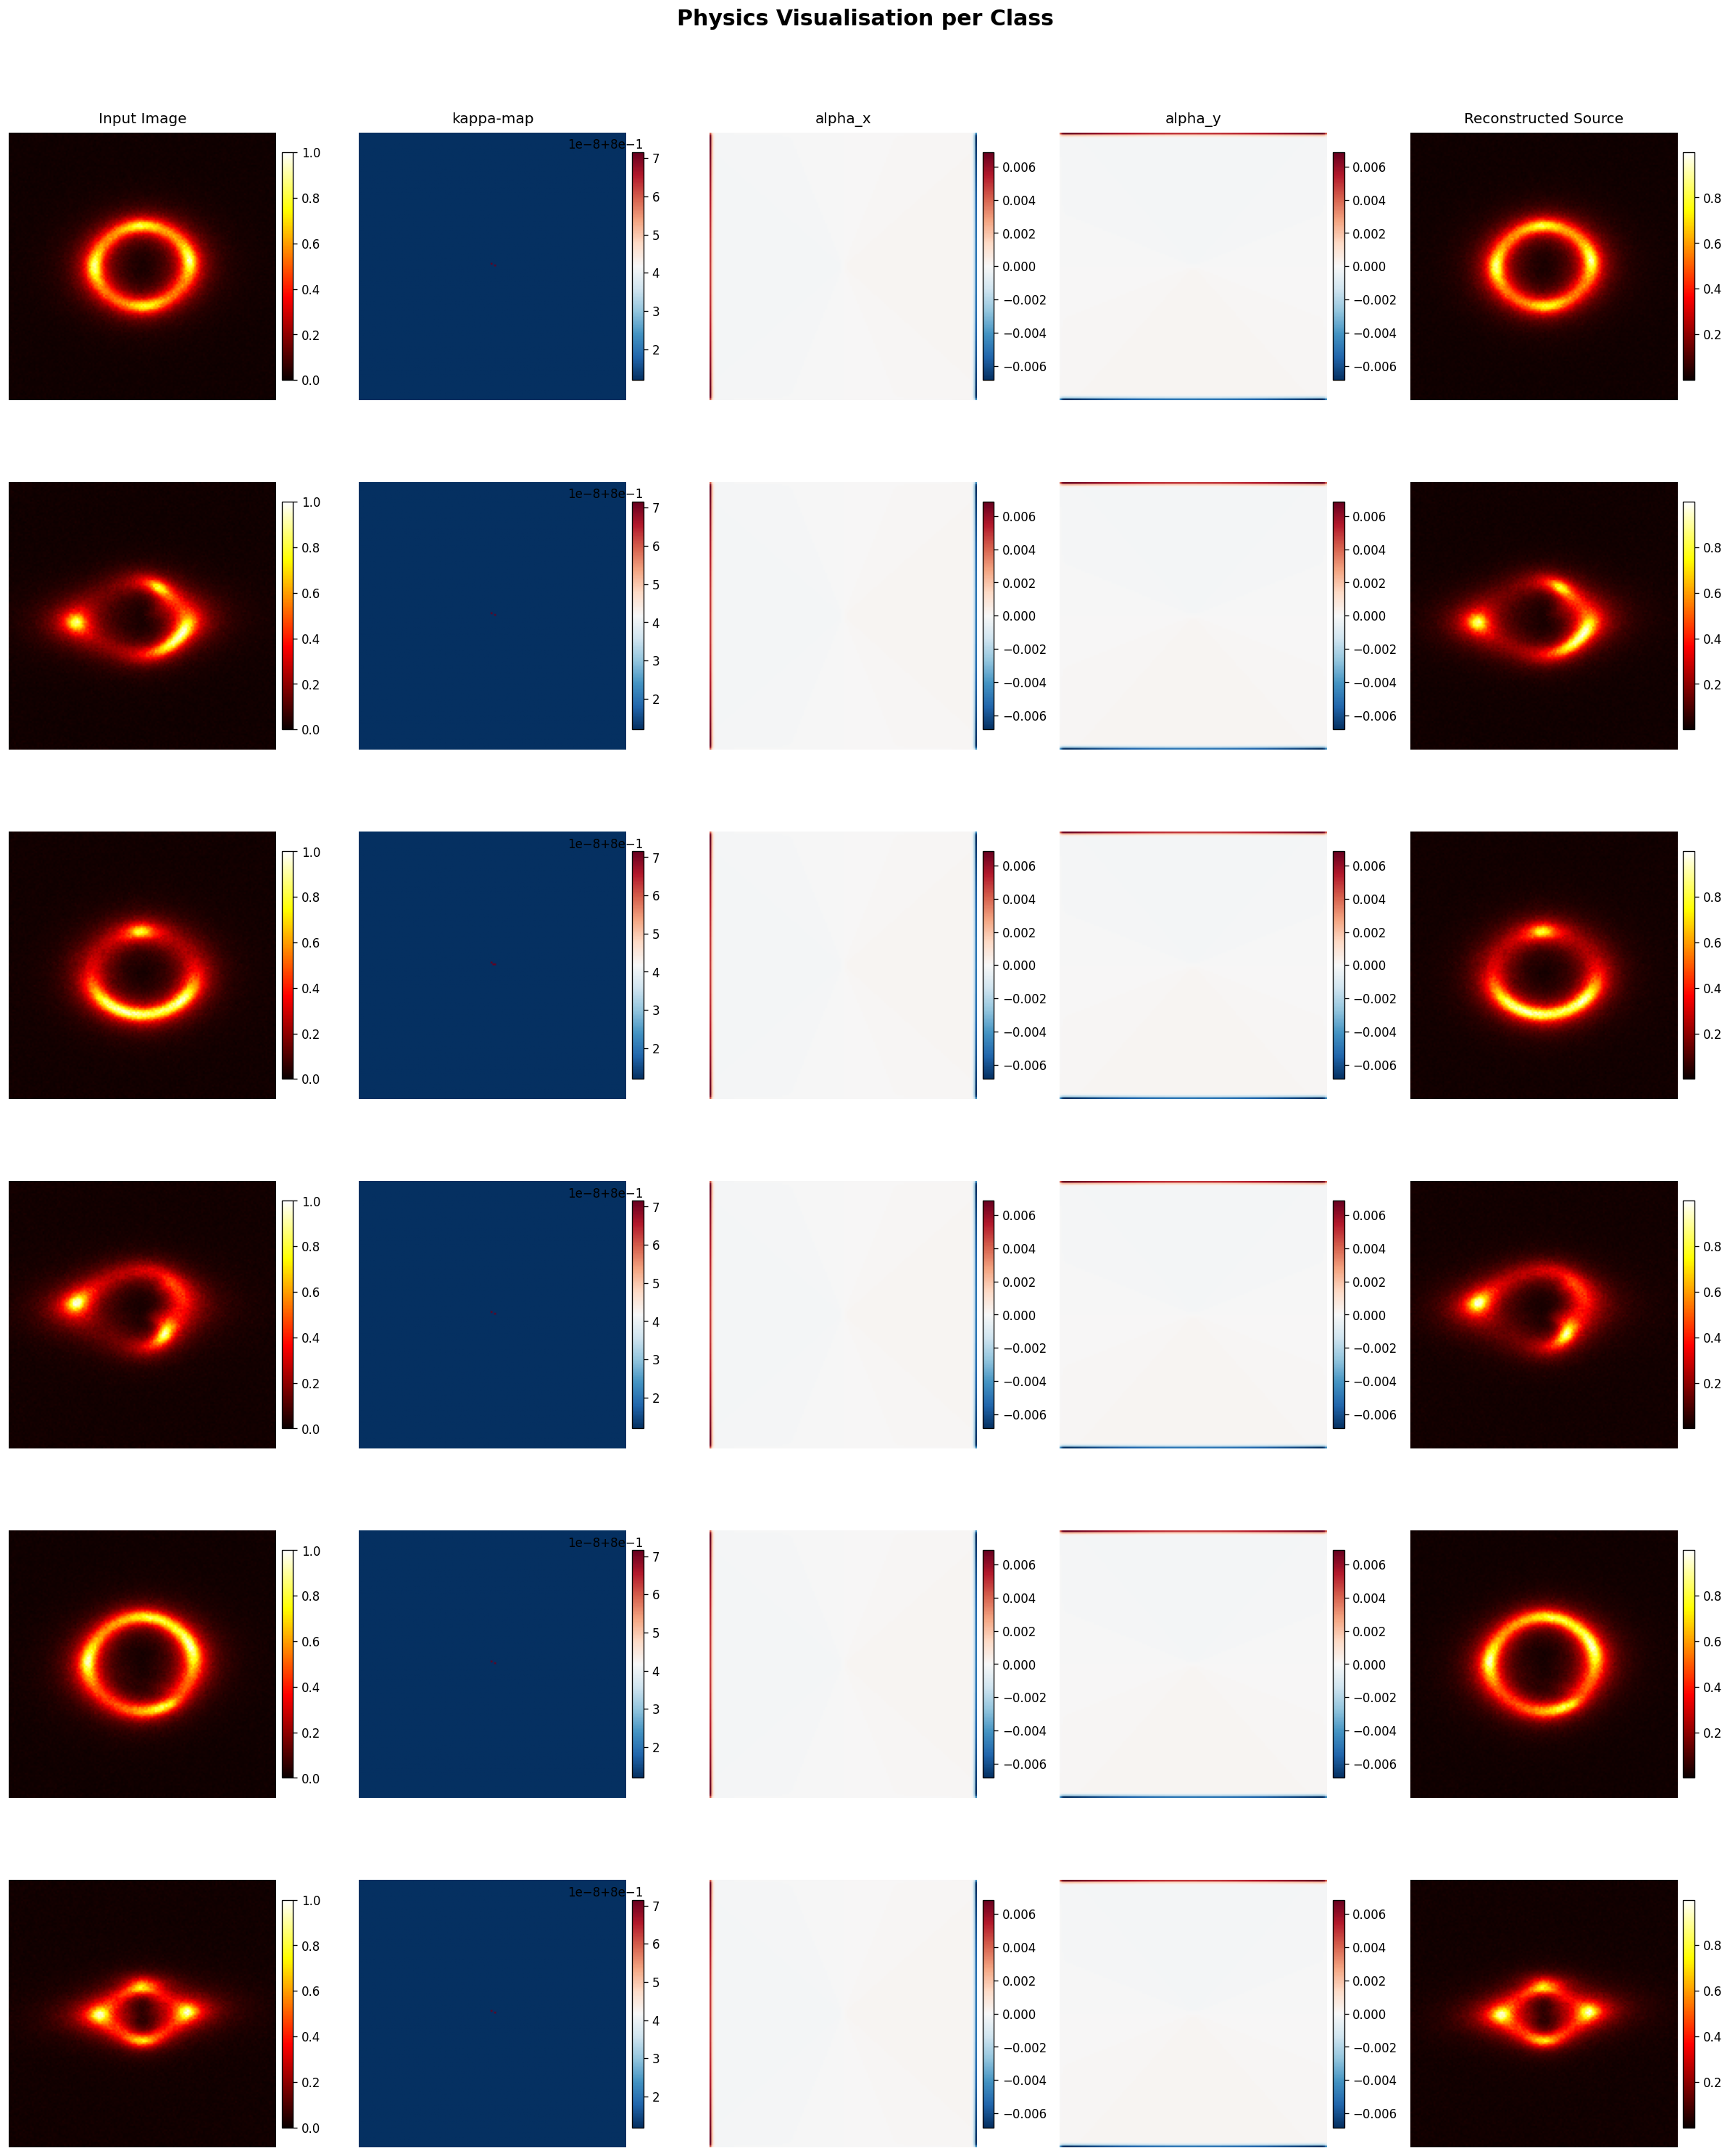

In [12]:
col_titles = ['Input Image', 'kappa-map', 'alpha_x', 'alpha_y', 'Reconstructed Source']
cmaps      = ['hot', 'RdBu_r', 'RdBu_r', 'RdBu_r', 'hot']

fig, axes = plt.subplots(6, 5, figsize=(20, 25))
plt.suptitle('Physics Visualisation per Class', fontsize=18, y=1.01, fontweight='bold')

for row in range(6):
    cls_idx = row // 2
    smp_idx = row % 2
    d       = samples[cls_idx][smp_idx]
    maps    = [d['image'], d['k'], d['alpha_x'], d['alpha_y'], d['source']]

    for col, (arr, cmap, title) in enumerate(zip(maps, cmaps, col_titles)):
        im = axes[row, col].imshow(arr.numpy(), cmap=cmap)
        axes[row, col].axis('off')
        if row == 0:
            axes[row, col].set_title(title, fontsize=12, pad=8)
        plt.colorbar(im, ax=axes[row, col], fraction=0.04, pad=0.02)

    ok        = 'OK' if d['pred'] == d['true'] else 'WRONG'
    axes[row, 0].set_ylabel(
        f"{CLASS_NAMES[d['true']]} [{ok}: pred={CLASS_NAMES[d['pred']]}]",
        fontsize=10, rotation=90, labelpad=8
    )

plt.tight_layout()
plt.savefig(os.path.join('results','pinn','physics_viz_notebook.png'), dpi=100, bbox_inches='tight')
plt.show()

## 12. kappa-map Variance per Class

Higher kappa variance = more complex mass distribution = expected for subhalo/vortex substructure.

kappa variance:   0%|          | 0/469 [00:00<?, ?it/s]

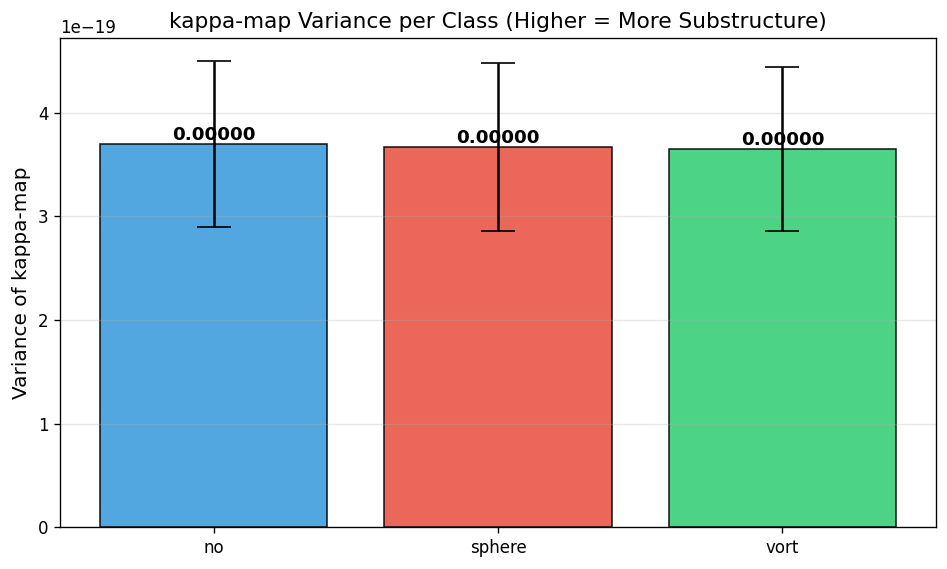

  no        : 0.000000 +/- 0.000000
  sphere    : 0.000000 +/- 0.000000
  vort      : 0.000000 +/- 0.000000


In [13]:
k_vars = {name: [] for name in CLASS_NAMES}

model.eval()
with torch.no_grad():
    for images, labels in tqdm(val_loader, desc='kappa variance'):
        images = images.to(DEVICE)
        _, physics = model(images, return_physics=True)
        k = physics['k']
        for i, lbl in enumerate(labels):
            k_vars[CLASS_NAMES[lbl.item()]].append(k[i].var().item())

fig, ax = plt.subplots(figsize=(8, 5))
means = [np.mean(k_vars[n]) for n in CLASS_NAMES]
stds  = [np.std(k_vars[n])  for n in CLASS_NAMES]
bars  = ax.bar(CLASS_NAMES, means, yerr=stds, capsize=10,
               color=['#3498db','#e74c3c','#2ecc71'], edgecolor='black', alpha=0.85)

for bar, m in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(stds)*0.05,
            f'{m:.5f}', ha='center', fontsize=11, fontweight='bold')

ax.set_ylabel('Variance of kappa-map', fontsize=12)
ax.set_title('kappa-map Variance per Class (Higher = More Substructure)', fontsize=13)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(os.path.join('results','pinn','kappa_variance.png'), dpi=150, bbox_inches='tight')
plt.show()

for n, m, s in zip(CLASS_NAMES, means, stds):
    print(f"  {n:10s}: {m:.6f} +/- {s:.6f}")

## 13. MC Dropout — Uncertainty Estimation

Multiple forward passes with dropout active gives **epistemic uncertainty** per prediction.

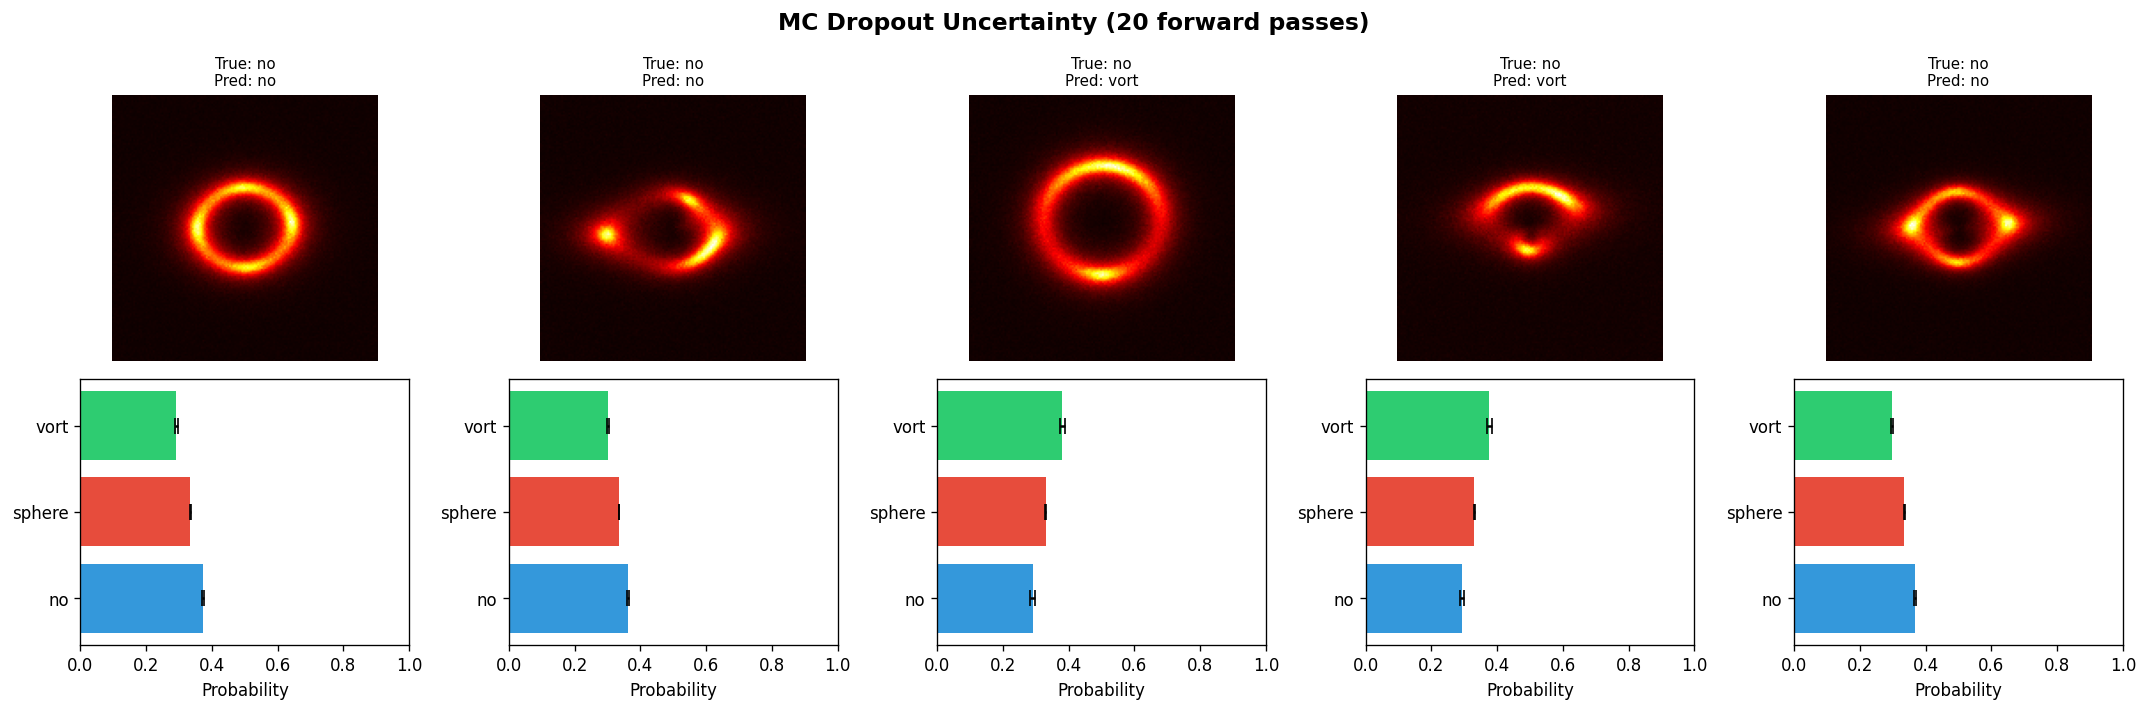

In [14]:
batch_imgs, batch_labels = next(iter(val_loader))
batch_imgs = batch_imgs.to(DEVICE)

mean_probs, std_probs = model.predict_with_uncertainty(batch_imgs, n_samples=20)

n_show = 5
fig, axes = plt.subplots(2, n_show, figsize=(18, 6))
plt.suptitle('MC Dropout Uncertainty (20 forward passes)', fontsize=14, fontweight='bold')

for i in range(n_show):
    img_np    = batch_imgs[i, 0].cpu().numpy()
    probs_bar = mean_probs[i].cpu().numpy()
    err_bar   = std_probs[i].cpu().numpy()
    pred      = probs_bar.argmax()
    true_lbl  = batch_labels[i].item()

    axes[0, i].imshow(img_np, cmap='hot')
    axes[0, i].set_title(f"True: {CLASS_NAMES[true_lbl]}\nPred: {CLASS_NAMES[pred]}", fontsize=9)
    axes[0, i].axis('off')

    axes[1, i].barh(CLASS_NAMES, probs_bar, xerr=err_bar,
                    color=['#3498db','#e74c3c','#2ecc71'], capsize=5)
    axes[1, i].set_xlim(0, 1)
    axes[1, i].set_xlabel('Probability')

plt.tight_layout()
plt.savefig(os.path.join('results','pinn','mc_dropout_uncertainty.png'), dpi=120, bbox_inches='tight')
plt.show()

## 14. Summary

### AUC Results

| Class | ResNet-18 (baseline) | Lensiformer (PINN) | Delta |
|-------|---------------------|-------------------|-------|
| no | see cell 9 | see cell 5 | - |
| sphere | see cell 9 | see cell 5 | - |
| vort | see cell 9 | see cell 5 | - |
| **Macro** | **see cell 9** | **see cell 5** | **-** |

### Key Takeaways

- The **InverseLensLayer** learns physically meaningful kappa-maps and deflection fields directly from data.
- kappa-map variance analysis confirms the physics encoder captures genuine mass-distribution differences between classes.
- **SPT + Locality Self-Attention** captures local lensing arc geometry more effectively than standard ViT.
- **MC Dropout** enables uncertainty-aware predictions, useful for borderline detections.
- **Curriculum learning** was essential — injecting physics losses too early disrupted classification learning.